# Стратификация по surface и корреляционный анализ

Цели:
1. Проверить качество моделей на разных покрытиях (Hard, Clay, Grass)
2. Построить корреляционную матрицу признаков
3. Обсудить влияние мультиколлинеарности на интерпретацию

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

ods = pd.read_parquet('ods.parquet')
tml = pd.read_parquet('tml.parquet')

ods['Date'] = pd.to_datetime(ods['Date'])
tml['tourney_date'] = pd.to_datetime(tml['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')

## 1. Подготовка данных

In [2]:
import re

def key_from_odds(name: str) -> str:
    if pd.isna(name):
        return ''
    s = str(name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    init = re.sub(r"[^a-z]", "", parts[-1].replace('.', ''))[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[:-1])).strip()
    return f"{surname} {init}".strip()

def key_from_tml(full_name: str) -> str:
    if pd.isna(full_name):
        return ''
    s = str(full_name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    if len(parts) == 1:
        return re.sub(r"[^a-z]", "", parts[0])
    init = re.sub(r"[^a-z]", "", parts[0])[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[1:])).strip()
    return f"{surname} {init}".strip()

ods['week'] = (ods['Date'] - pd.to_timedelta(ods['Date'].dt.weekday, unit='D')).dt.normalize()
tml['week'] = tml['tourney_date'].dt.normalize()

ods['wkey'] = ods['Winner'].map(key_from_odds)
ods['lkey'] = ods['Loser'].map(key_from_odds)
tml['wkey'] = tml['winner_name'].map(key_from_tml)
tml['lkey'] = tml['loser_name'].map(key_from_tml)

ods['p1'] = ods[['wkey', 'lkey']].min(axis=1)
ods['p2'] = ods[['wkey', 'lkey']].max(axis=1)
tml['p1'] = tml[['wkey', 'lkey']].min(axis=1)
tml['p2'] = tml[['wkey', 'lkey']].max(axis=1)

joined = tml.merge(ods, how='inner', on=['week', 'p1', 'p2'], suffixes=('_tml', '_ods'))
print('joined shape:', joined.shape)

joined shape: (17633, 99)


In [3]:
# Build features
joined['winner_key'] = joined['winner_name'].map(key_from_tml)
joined['loser_key'] = joined['loser_name'].map(key_from_tml)
joined['y_p1_win'] = (joined['winner_key'] == joined['p1']).astype(int)

joined['rank_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank'], joined['loser_rank'])
joined['rank_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank'], joined['loser_rank'])
joined['rank_diff_p1_minus_p2'] = joined['rank_p1'] - joined['rank_p2']

joined['rank_points_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_diff_p1_minus_p2'] = joined['rank_points_p1'] - joined['rank_points_p2']

joined['ps_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['PSW'], joined['PSL'])
joined['ps_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['PSW'], joined['PSL'])

p1 = 1.0 / joined['ps_odds_p1']
p2 = 1.0 / joined['ps_odds_p2']
s = p1 + p2
joined['ps_imp_p1'] = p1 / s

# Surface (lowercase for consistency)
joined['surface'] = joined['surface'].str.lower()

# Fill NaN
for c in ['ps_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2']:
    if c in joined.columns:
        joined[c] = joined[c].fillna(joined[c].median())

print('Features ready')

Features ready


## 2. Распределение матчей по surface

In [4]:
print('=== Matches by surface ===')
print(joined['surface'].value_counts())

=== Matches by surface ===
surface
hard     10106
clay      5417
grass     2110
Name: count, dtype: int64


## 3. Качество baseline (PS implied prob) по surface

In [5]:
# Time-based split
cutoff = pd.Timestamp('2024-01-01')
test_df = joined[joined['week'] >= cutoff].copy()

def eval_baseline(y_true, p_pred):
    mask = np.isfinite(p_pred) & np.isfinite(y_true)
    y = y_true[mask].astype(int)
    p = p_pred[mask].clip(1e-6, 1-1e-6)
    return {
        'n': len(y),
        'logloss': log_loss(y, p),
        'roc_auc': roc_auc_score(y, p),
        'acc@0.5': accuracy_score(y, p >= 0.5),
    }

print('=== Baseline (PS) by surface on test 2024+ ===')
baseline_by_surface = []
for surface in ['hard', 'clay', 'grass']:
    sub = test_df[test_df['surface'] == surface]
    if len(sub) > 0:
        res = eval_baseline(sub['y_p1_win'], sub['ps_imp_p1'].to_numpy())
        res['surface'] = surface
        baseline_by_surface.append(res)

baseline_df = pd.DataFrame(baseline_by_surface)
print(baseline_df[['surface', 'n', 'logloss', 'roc_auc', 'acc@0.5']])

=== Baseline (PS) by surface on test 2024+ ===
  surface     n   logloss   roc_auc   acc@0.5
0    hard  1866  0.598867  0.740148  0.669346
1    clay  1145  0.612139  0.720851  0.661135
2   grass   524  0.584103  0.753074  0.694656


## 4. Качество LR по surface

In [6]:
features = ['ps_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2']

# Train on all data before cutoff
train_df = joined[(joined['week'] < cutoff)].copy()
X_train = train_df[features].fillna(train_df[features].median())
y_train = train_df['y_p1_win']

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

print('=== LR by surface on test 2024+ ===')
lr_by_surface = []
for surface in ['hard', 'clay', 'grass']:
    sub = test_df[test_df['surface'] == surface].copy()
    if len(sub) > 0:
        X_test = sub[features].fillna(train_df[features].median())
        p = lr.predict_proba(X_test)[:, 1]
        res = eval_baseline(sub['y_p1_win'], p)
        res['surface'] = surface
        lr_by_surface.append(res)

lr_df = pd.DataFrame(lr_by_surface)
print(lr_df[['surface', 'n', 'logloss', 'roc_auc', 'acc@0.5']])

=== LR by surface on test 2024+ ===
  surface     n   logloss   roc_auc   acc@0.5
0    hard  1866  0.598972  0.740187  0.673633
1    clay  1145  0.612255  0.720790  0.662882
2   grass   524  0.585440  0.753190  0.690840


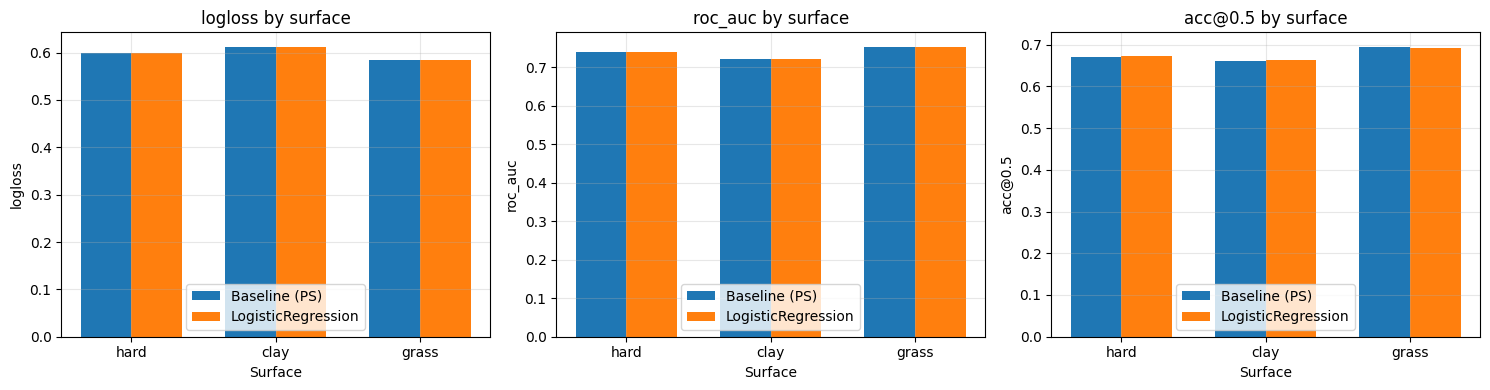

In [7]:
# Combined comparison plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['logloss', 'roc_auc', 'acc@0.5']):
    x = np.arange(3)
    width = 0.35
    surfaces = ['hard', 'clay', 'grass']
    
    baseline_vals = [baseline_df[baseline_df['surface']==s][metric].values[0] for s in surfaces if s in baseline_df['surface'].values]
    lr_vals = [lr_df[lr_df['surface']==s][metric].values[0] for s in surfaces if s in lr_df['surface'].values]
    
    ax.bar(x - width/2, baseline_vals, width, label='Baseline (PS)')
    ax.bar(x + width/2, lr_vals, width, label='LogisticRegression')
    ax.set_xlabel('Surface')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by surface')
    ax.set_xticks(x)
    ax.set_xticklabels(surfaces[:len(baseline_vals)])
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/metrics_by_surface.png', dpi=150)
plt.show()

## 5. Корреляционная матрица признаков

In [8]:
# Extended feature set for correlation analysis
extended_features = [
    'ps_imp_p1',
    'rank_diff_p1_minus_p2',
    'rank_points_diff_p1_minus_p2',
    'y_p1_win',
]

corr_df = joined[extended_features].dropna()

print('=== Correlation matrix ===')
corr = corr_df.corr()
print(corr.round(3))

=== Correlation matrix ===
                              ps_imp_p1  rank_diff_p1_minus_p2  \
ps_imp_p1                         1.000                 -0.519   
rank_diff_p1_minus_p2            -0.519                  1.000   
rank_points_diff_p1_minus_p2      0.712                 -0.385   
y_p1_win                          0.430                 -0.220   

                              rank_points_diff_p1_minus_p2  y_p1_win  
ps_imp_p1                                            0.712      0.43  
rank_diff_p1_minus_p2                               -0.385     -0.22  
rank_points_diff_p1_minus_p2                         1.000      0.30  
y_p1_win                                             0.300      1.00  


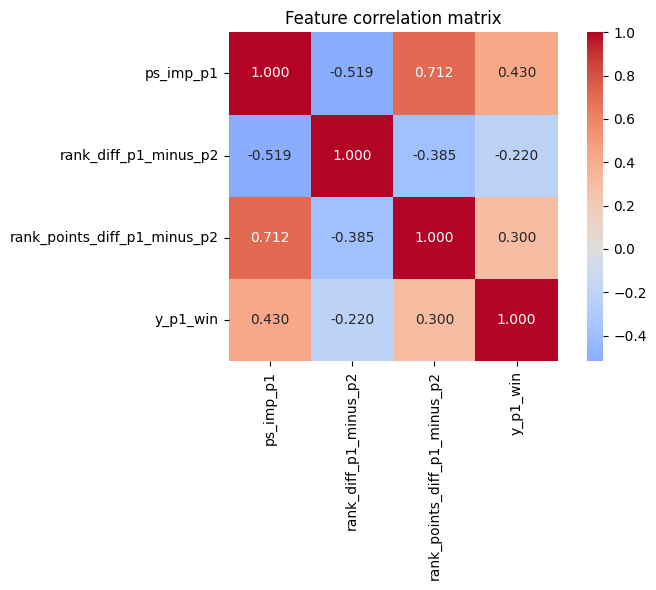

In [9]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('figures/feature_correlation_matrix.png', dpi=150)
plt.show()

## 6. VIF (Variance Inflation Factor) для проверки мультиколлинеарности

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = corr_df[['ps_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2']]
X = add_constant(X)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print('=== VIF (Variance Inflation Factor) ===')
print('VIF > 10 indicates high multicollinearity')
print(vif_data)

=== VIF (Variance Inflation Factor) ===
VIF > 10 indicates high multicollinearity
                        feature        VIF
0                         const  13.990388
1                     ps_imp_p1   2.366666
2         rank_diff_p1_minus_p2   1.369286
3  rank_points_diff_p1_minus_p2   2.031121


## 7. Выводы

Ожидаемые результаты:

1. **По surface**: качество может отличаться (например, на grass меньше матчей, выше вариативность).

2. **Корреляции**:
   - `ps_imp_p1` сильно коррелирует с `rank_points_diff` (букмекер учитывает рейтинг)
   - `rank_diff` и `rank_points_diff` коррелируют между собой

3. **Мультиколлинеарность**: если VIF > 10, интерпретация весов LR затруднена.

4. **Интерпретация**: при наличии сильных корреляций веса LR не отражают "чистый" вклад признака, а зависят от других признаков в модели.